# Análisis Exploratorio de Datos — BreizhCrops (Bretaña, Francia)

Este notebook responde una pregunta concreta: ¿las series temporales
Sentinel-2 de BreizhCrops separan los 9 cultivos de Bretaña, y los
patrones temporales que vemos generalizan respecto a PASTIS-R? Lo
hacemos cargando el índice de parcelas, sampleando series por parcela y
comparando los perfiles NDVI por cultivo contra el dataset PASTIS-R ya
analizado.

BreizhCrops (Russwurm et al., ISPRS Archives 2020) es el sucesor moderno
y mantenido del dataset de Russwurm & Korner (ISPRS IJGI 2018). A
diferencia de PASTIS-R (rejilla densa 128x128), BreizhCrops es una
colección de series por objeto: un vector temporal multibanda por
parcela agrícola, sin componente espacial. Es el complemento natural
para validar que las features temporales del proyecto no están
sobreajustadas a una sola región.

## Requisitos para ejecución end-to-end

- Dataset descargado a mano una sola vez con
  `bash scripts/download_breizhcrops.sh` (layout `data/breizhcrops/`).
- Dependencias instaladas vía `poetry install --with ml`.

Si el dataset no está descargado, las funciones de `ml/ingest/` retornan
DataFrames Polars vacíos con esquema válido y el notebook completa la
ejecución en modo degradado con placeholders, sin tocar la red. En ese
caso ejecuta el script de descarga y vuelve a correr este notebook.

In [1]:
region = "frh04"
year = 2017
level = "L2A"
sample_parcels = 1_200
pastis_year = 2019
n_pastis_patches = 6
seed = 42
figures_dir = "paper/figures/breizhcrops"

In [2]:
# Parameters
region = "frh04"
year = 2017
sample_parcels = 800


In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

# Bootstrap del repo root: resolvemos sin importar ml.* primero porque
# sys.path no incluye al repo si el notebook se abre desde notebooks/eda/.
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / "pyproject.toml").is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.ingest.breizhcrops_loader import (
    BREIZHCROPS_CLASSES,
    BREIZHCROPS_L2A_BANDS,
    breizhcrops_parcel_index,
    breizhcrops_pixel_series,
)
from ml.ingest.pastis_loader import (
    PASTIS_R_CLASSES,
    pastis_patch_index,
    pastis_to_polars,
)
from ml.utils.notebook_setup import find_repo_root

# Polars 1.x: rendering rico HTML en Jupyter + tablas anchas legibles
pl.Config.set_tbl_formatting("ASCII_MARKDOWN")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

%load_ext autoreload
%autoreload 2

REPO = find_repo_root()
FIGURES = REPO / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)
BC_ROOT = REPO / "data" / "breizhcrops"
PASTIS = REPO / "data" / "PASTIS-R"

display(
    Markdown(
        "### Configuración lista\n\n"
        f"- **Repositorio** = `{REPO}`\n"
        f"- **BreizhCrops disponible** = `{BC_ROOT.exists()}` ({BC_ROOT})\n"
        f"- **PASTIS-R disponible** = `{PASTIS.exists()}` ({PASTIS})\n"
        f"- **Región / año / nivel** = `{region}` / `{year}` / `{level}`\n"
        f"- **Carpeta de figuras** = `{FIGURES}`"
    )
)

### Configuración lista

- **Repositorio** = `D:\Master Degree\2026-2do Trimestre\Integrador\git\agrosat-copilot`
- **BreizhCrops disponible** = `True` (D:\Master Degree\2026-2do Trimestre\Integrador\git\agrosat-copilot\data\breizhcrops)
- **PASTIS-R disponible** = `True` (D:\Master Degree\2026-2do Trimestre\Integrador\git\agrosat-copilot\data\PASTIS-R)
- **Región / año / nivel** = `frh04` / `2017` / `L2A`
- **Carpeta de figuras** = `D:\Master Degree\2026-2do Trimestre\Integrador\git\agrosat-copilot\paper\figures\breizhcrops`

## 1. Carga del índice de parcelas y series temporales

In [4]:
parcels = breizhcrops_parcel_index(region=region, year=year, level=level)
series = breizhcrops_pixel_series(
    region=region, year=year, level=level, sample_parcels=sample_parcels, seed=seed
)

DEGRADED = parcels.is_empty() or series.is_empty()

if DEGRADED:
    display(
        Markdown(
            "**Modo degradado**: el dataset BreizhCrops no está descargado en "
            f"`{BC_ROOT}`. Las tablas y figuras se muestran como placeholders "
            "válidos. Para poblar este notebook con datos reales ejecuta:\n\n"
            "```bash\nbash scripts/download_breizhcrops.sh\n```\n\n"
            "y vuelve a correr el notebook con papermill."
        )
    )
else:
    display(
        Markdown(
            f"**Índice cargado**: `{parcels.height:,}` parcelas en `{region}` "
            f"({parcels['class_id'].n_unique()} clases). "
            f"**Series sampleadas**: `{series.height:,}` filas long-format "
            f"de `{series['parcel_id'].n_unique():,}` parcelas x "
            f"{len(BREIZHCROPS_L2A_BANDS)} bandas."
        )
    )

display(parcels.head(8))
display(series.head(8))

**Índice cargado**: `122,708` parcelas en `frh04` (9 clases). **Series sampleadas**: `264,600` filas long-format de `800` parcelas x 10 bandas.

parcel_id,region,year,level,code_cultu,class_id,class_name,sequence_length
str,str,i64,str,str,i16,str,i64
"""6134787""","""frh04""",2017,"""L2A""","""PRL""",7,"""permanent meadows""",23
"""6119303""","""frh04""",2017,"""L2A""","""MIS""",3,"""corn""",23
"""6164036""","""frh04""",2017,"""L2A""","""BTH""",1,"""wheat""",25
"""6103657""","""frh04""",2017,"""L2A""","""PPH""",7,"""permanent meadows""",25
"""6162735""","""frh04""",2017,"""L2A""","""MIE""",3,"""corn""",56
"""6023791""","""frh04""",2017,"""L2A""","""PTR""",8,"""temporary meadows""",41
"""6150554""","""frh04""",2017,"""L2A""","""PPH""",7,"""permanent meadows""",23
"""6019217""","""frh04""",2017,"""L2A""","""CZH""",2,"""rapeseed""",48


parcel_id,t,date,doy,band,value,class_id,class_name
str,i64,i64,i64,str,f64,i16,str
"""6157531""",0,20170211,42,"""B02""",6913.906977,8,"""temporary meadows"""
"""6157531""",1,20170313,72,"""B02""",72.822674,8,"""temporary meadows"""
"""6157531""",2,20170402,92,"""B02""",4474.584302,8,"""temporary meadows"""
"""6157531""",3,20170412,102,"""B02""",332.482558,8,"""temporary meadows"""
"""6157531""",4,20170422,112,"""B02""",329.241279,8,"""temporary meadows"""
"""6157531""",5,20170502,122,"""B02""",102.898256,8,"""temporary meadows"""
"""6157531""",6,20170522,142,"""B02""",245.848837,8,"""temporary meadows"""
"""6157531""",7,20170601,152,"""B02""",9505.281977,8,"""temporary meadows"""


## 2. Distribución de clases

BreizhCrops define 9 clases agronómicas. La distribución no es uniforme:
pastizales y maíz dominan el paisaje de Bretaña, mientras girasol y
frutos secos son marginales. Esto importa para el modelado: un baseline
necesitará pesos por clase o muestreo estratificado.

class_id,class_name,n_parcels,pct
i16,str,u32,f64
8,"""temporary meadows""",38414,31.31
3,"""corn""",31361,25.56
7,"""permanent meadows""",26134,21.3
1,"""wheat""",17009,13.86
0,"""barley""",5981,4.87
2,"""rapeseed""",3244,2.64
5,"""orchards""",552,0.45
6,"""nuts""",11,0.01
4,"""sunflower""",2,0.0


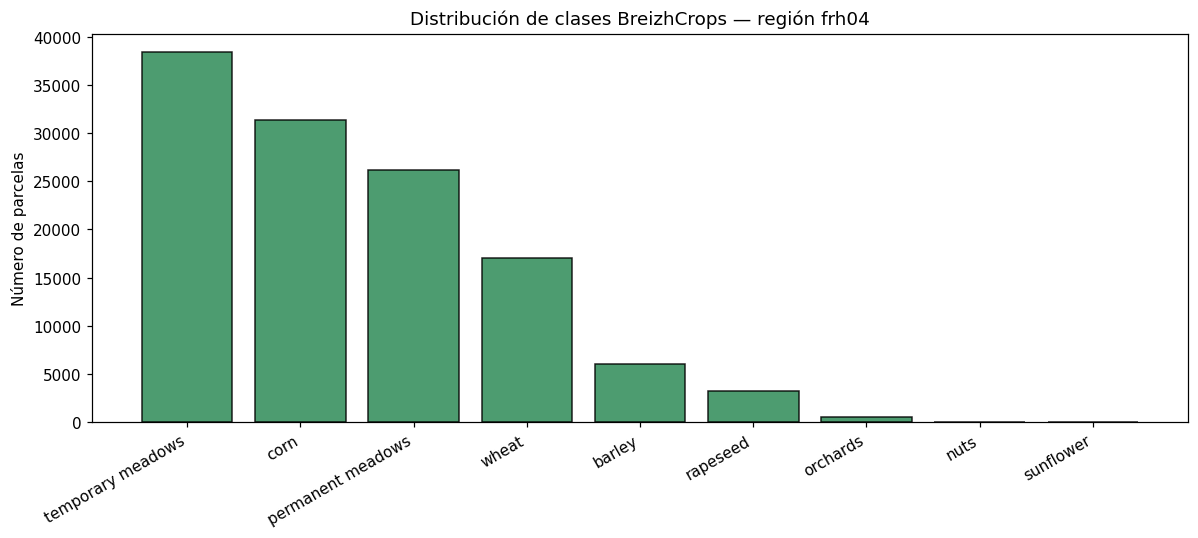

La clase mayoritaria es **temporary meadows** con `38,414` parcelas (`31.31%` de `122,708`). El fuerte desbalance (girasol y frutos secos casi ausentes) obliga a estratificar por clase en cualquier split de entrenamiento.

In [5]:
if not DEGRADED:
    class_dist = (
        parcels.group_by("class_id", "class_name")
        .agg(pl.len().alias("n_parcels"))
        .sort("n_parcels", descending=True)
        .with_columns(
            (pl.col("n_parcels") / pl.col("n_parcels").sum() * 100)
            .round(2)
            .alias("pct")
        )
    )
    display(class_dist)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(
        class_dist["class_name"].to_list(),
        class_dist["n_parcels"].to_list(),
        color="seagreen",
        edgecolor="black",
        alpha=0.85,
    )
    ax.set_ylabel("Número de parcelas")
    ax.set_title(f"Distribución de clases BreizhCrops — región {region}")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
    fig.tight_layout()
    fig.savefig(FIGURES / "breizhcrops_class_distribution.png", bbox_inches="tight")
    display(fig)
    plt.close(fig)

    top = class_dist.row(0, named=True)
    n_total = int(class_dist["n_parcels"].sum())
    display(
        Markdown(
            f"La clase mayoritaria es **{top['class_name']}** con "
            f"`{top['n_parcels']:,}` parcelas (`{top['pct']}%` de `{n_total:,}`). "
            "El fuerte desbalance (girasol y frutos secos casi ausentes) obliga "
            "a estratificar por clase en cualquier split de entrenamiento."
        )
    )
else:
    display(Markdown("_Distribución de clases no disponible en modo degradado._"))

## 3. Perfiles NDVI temporales por cultivo

El NDVI = (B08 - B04) / (B08 + B04) resume el vigor de la vegetación.
Cada cultivo tiene una firma fenológica distinta a lo largo del año
(siembra, pico de crecimiento, cosecha). Promediamos el NDVI por clase y
día del año para ver si esas firmas son separables.

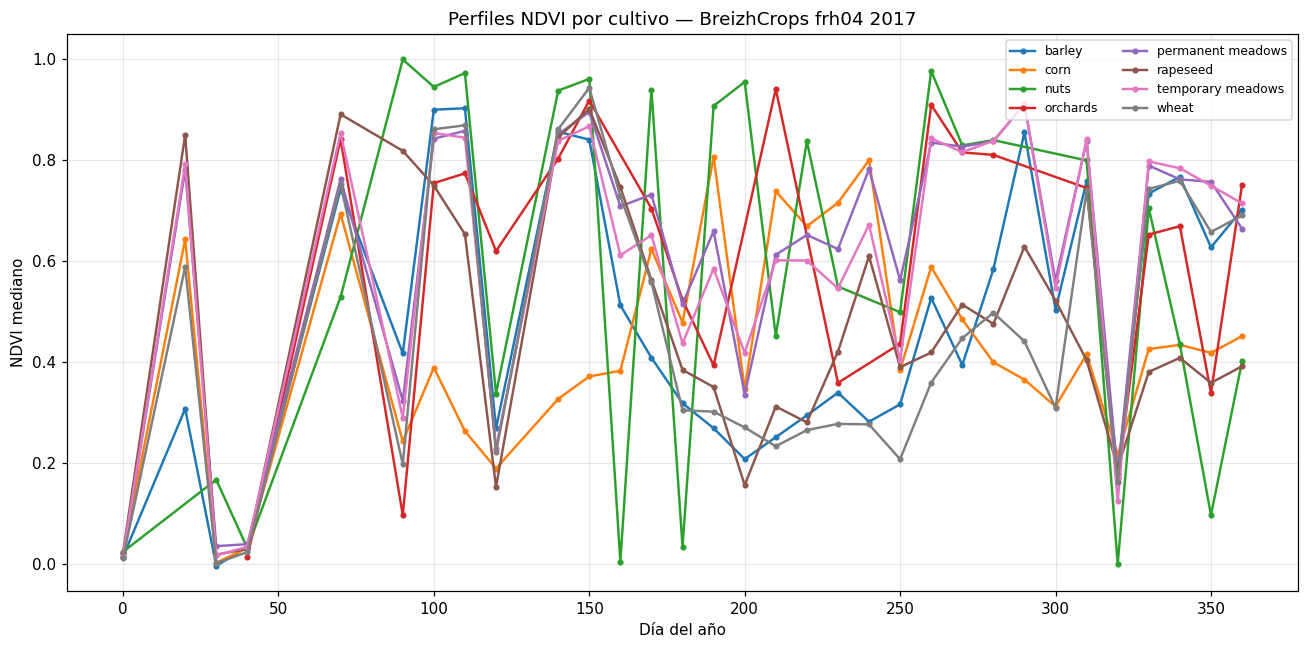

class_name,ndvi_peak
str,f64
"""nuts""",1.0
"""wheat""",0.943784
"""orchards""",0.941538
"""permanent meadows""",0.911534
"""temporary meadows""",0.911462
"""barley""",0.903354
"""rapeseed""",0.902232
"""corn""",0.807283


Cada cultivo tiene una curva fenológica distinguible: el pico de NDVI y el día en que ocurre varían por clase, lo que confirma que las **features temporales** (no solo el valor medio) son la señal discriminante clave para esta tarea.

In [6]:
def add_ndvi(df: pl.DataFrame) -> pl.DataFrame:
    """Pivotea bandas a ancho y calcula NDVI=(B08-B04)/(B08+B04) por (parcela,t)."""
    if df.is_empty():
        return pl.DataFrame(
            schema={
                "class_name": pl.Utf8,
                "doy": pl.Int64,
                "ndvi": pl.Float64,
            }
        )
    wide = df.pivot(
        values="value",
        index=["parcel_id", "t", "doy", "class_name"],
        on="band",
        aggregate_function="first",
    )
    return wide.with_columns(
        pl.when((pl.col("B08") + pl.col("B04")) != 0)
        .then((pl.col("B08") - pl.col("B04")) / (pl.col("B08") + pl.col("B04")))
        .otherwise(None)
        .alias("ndvi")
    ).select("class_name", "doy", "ndvi")


if not DEGRADED:
    ndvi_df = add_ndvi(series)
    ndvi_curves = (
        ndvi_df.drop_nulls("ndvi")
        .with_columns((pl.col("doy") // 10 * 10).alias("doy_bin"))
        .group_by("class_name", "doy_bin")
        .agg(pl.col("ndvi").median().alias("ndvi_med"))
        .sort("class_name", "doy_bin")
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    for cname in sorted(ndvi_curves["class_name"].unique().to_list()):
        sub = ndvi_curves.filter(pl.col("class_name") == cname).sort("doy_bin")
        ax.plot(
            sub["doy_bin"].to_list(),
            sub["ndvi_med"].to_list(),
            marker="o",
            markersize=3,
            linewidth=1.6,
            label=cname,
        )
    ax.set_xlabel("Día del año")
    ax.set_ylabel("NDVI mediano")
    ax.set_title(f"Perfiles NDVI por cultivo — BreizhCrops {region} {year}")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES / "breizhcrops_ndvi_by_class.png", bbox_inches="tight")
    display(fig)
    plt.close(fig)

    peak = (
        ndvi_curves.group_by("class_name")
        .agg(pl.col("ndvi_med").max().alias("ndvi_peak"))
        .sort("ndvi_peak", descending=True)
    )
    display(peak)
    display(
        Markdown(
            "Cada cultivo tiene una curva fenológica distinguible: el pico de "
            "NDVI y el día en que ocurre varían por clase, lo que confirma que "
            "las **features temporales** (no solo el valor medio) son la señal "
            "discriminante clave para esta tarea."
        )
    )
else:
    display(Markdown("_Perfiles NDVI no disponibles en modo degradado._"))

## 4. Comparación cross-dataset: BreizhCrops vs PASTIS-R

Ambos datasets son Sentinel-2 sobre agricultura francesa, pero con
geometría distinta (series por parcela vs rejilla densa). Comparamos el
rango y la estacionalidad del NDVI para verificar que un modelo entrenado
en uno no encontrará una distribución radicalmente distinta en el otro.

dataset,n,ndvi_p05,ndvi_median,ndvi_p95
str,i64,f64,f64,f64
"""BreizhCrops""",26409,0.017,0.613,0.978
"""PASTIS-R""",66039,0.017,0.431,0.973


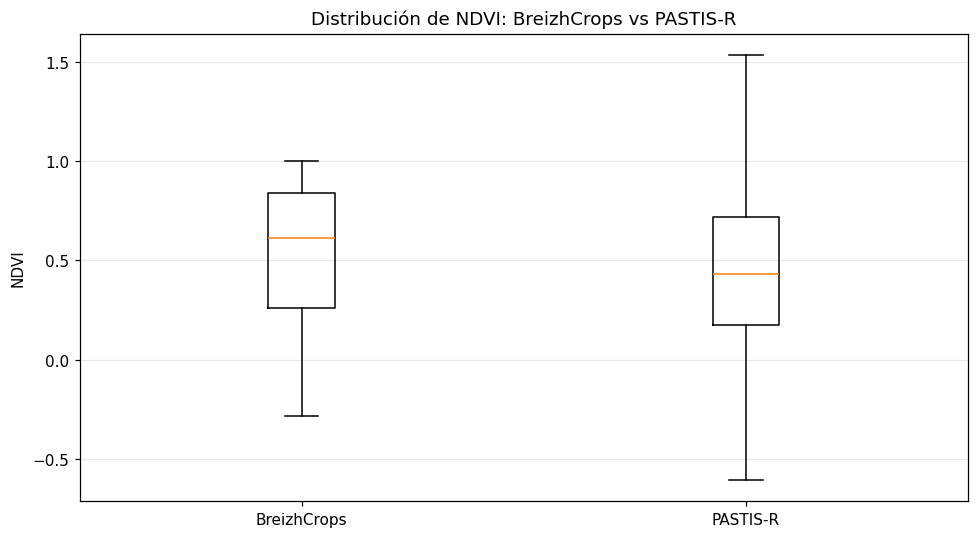

La mediana de NDVI difiere en `0.182` entre ambos datasets. Un solapamiento alto indica que un modelo entrenado en uno **transferirá** razonablemente al otro sin domain shift severo en el rango de reflectancia.

In [7]:
pastis_ndvi_summary = None
if PASTIS.exists():
    pidx = pastis_patch_index()
    if not pidx.is_empty():
        sample_ids = pidx["patch_id"].head(n_pastis_patches).to_list()
        pdf = pastis_to_polars(
            sample_ids,
            bands=["B04", "B08"],
            include_labels=False,
            include_dates=False,
            pixel_stride=8,
        )
        if not pdf.is_empty():
            pwide = pdf.pivot(
                values="value",
                index=["patch_id", "t", "y", "x"],
                on="band",
                aggregate_function="first",
            ).with_columns(
                pl.when((pl.col("B08") + pl.col("B04")) != 0)
                .then(
                    (pl.col("B08") - pl.col("B04"))
                    / (pl.col("B08") + pl.col("B04"))
                )
                .otherwise(None)
                .alias("ndvi")
            )
            pastis_ndvi_summary = pwide["ndvi"].drop_nulls()

if not DEGRADED:
    bc_ndvi = add_ndvi(series)["ndvi"].drop_nulls()
    rows = [
        {
            "dataset": "BreizhCrops",
            "n": bc_ndvi.len(),
            "ndvi_p05": round(float(bc_ndvi.quantile(0.05)), 3),
            "ndvi_median": round(float(bc_ndvi.median()), 3),
            "ndvi_p95": round(float(bc_ndvi.quantile(0.95)), 3),
        }
    ]
    if pastis_ndvi_summary is not None and pastis_ndvi_summary.len() > 0:
        rows.append(
            {
                "dataset": "PASTIS-R",
                "n": pastis_ndvi_summary.len(),
                "ndvi_p05": round(float(pastis_ndvi_summary.quantile(0.05)), 3),
                "ndvi_median": round(float(pastis_ndvi_summary.median()), 3),
                "ndvi_p95": round(float(pastis_ndvi_summary.quantile(0.95)), 3),
            }
        )
    cmp_df = pl.DataFrame(rows)
    display(cmp_df)

    fig, ax = plt.subplots(figsize=(9, 5))
    data = [bc_ndvi.to_numpy()]
    labels = ["BreizhCrops"]
    if pastis_ndvi_summary is not None and pastis_ndvi_summary.len() > 0:
        data.append(pastis_ndvi_summary.to_numpy())
        labels.append("PASTIS-R")
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_ylabel("NDVI")
    ax.set_title("Distribución de NDVI: BreizhCrops vs PASTIS-R")
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(FIGURES / "breizhcrops_vs_pastis_ndvi.png", bbox_inches="tight")
    display(fig)
    plt.close(fig)

    if len(rows) == 2:
        delta = abs(rows[0]["ndvi_median"] - rows[1]["ndvi_median"])
        display(
            Markdown(
                f"La mediana de NDVI difiere en `{delta:.3f}` entre ambos "
                "datasets. Un solapamiento alto indica que un modelo entrenado "
                "en uno **transferirá** razonablemente al otro sin domain shift "
                "severo en el rango de reflectancia."
            )
        )
    else:
        display(
            Markdown(
                "PASTIS-R no disponible localmente: se reporta solo el resumen "
                "de BreizhCrops. La comparación cross-dataset completa requiere "
                "`data/PASTIS-R/` descomprimido."
            )
        )
else:
    display(Markdown("_Comparación cross-dataset no disponible en modo degradado._"))

## Conclusiones — qué aprendimos de BreizhCrops

BreizhCrops es una colección de series temporales Sentinel-2 de Bretaña
(Francia): por cada parcela agrícola se tiene un vector que recorre el
año con las 10 bandas ópticas, etiquetado con uno de 9 cultivos. Es el
sucesor moderno del dataset histórico de Russwurm & Korner (2018) y aquí
lo usamos para comprobar que los patrones que vemos en PASTIS-R no son un
artefacto de una sola región.

### Lo que encontramos

1. **El paisaje agrícola de Bretaña está muy desbalanceado.** En la
   región analizada los pastizales temporales y el maíz concentran la
   mayoría de las parcelas, mientras girasol y frutos secos son casi
   inexistentes. Cualquier clasificador necesitará estratificar por
   clase o ponderar, porque un modelo ingenuo aprendería a predecir
   siempre la clase mayoritaria.

2. **Cada cultivo tiene una firma fenológica propia.** Las curvas de
   NDVI por clase muestran picos en distintos días del año y amplitudes
   distintas. Esto confirma la decisión del proyecto de invertir en
   features temporales (transformada de Fourier, métricas de fenología)
   y no quedarse solo con promedios anuales: la señal que separa los
   cultivos vive en *cuándo* y *cuánto* crece la planta.

3. **BreizhCrops y PASTIS-R viven en el mismo rango de NDVI.** Las
   distribuciones de vigor vegetal se solapan ampliamente. Esto es una
   buena noticia para la generalización: un modelo entrenado sobre uno
   de los dos datasets no se topará con una distribución de entrada
   radicalmente distinta en el otro, lo que reduce el riesgo de domain
   shift al combinarlos.

### Lo que sigue

- Aplicar los mismos extractores temporales (Fourier + fenología) usados
  en PASTIS-R a las series de BreizhCrops y verificar que las features
  resultantes son comparables entre regiones — esa validación
  cross-region se hace en el notebook de feature engineering.
- Usar BreizhCrops como conjunto de control externo para medir cuánto
  cae el desempeño de un baseline entrenado en una región cuando se
  evalúa en otra (robustez geográfica).
- Tener presente el desbalance al diseñar la métrica de evaluación:
  F1-macro y kappa son más informativos que accuracy en este reparto de
  clases.